# Imports & Configurations

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from skimage.feature import hog
from skimage import exposure
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.svm import SVC
from tqdm import tqdm
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# Kagglehub download
import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("robinreni/signature-verification-dataset")
print("Dataset Path:", dataset_path)


Using Colab cache for faster access to the 'signature-verification-dataset' dataset.
Dataset Path: /kaggle/input/signature-verification-dataset


In [45]:
# Check main folder contents
print(os.listdir(dataset_path))

# Our folder structure:
train_path = os.path.join(dataset_path, "sign_data", "train")
test_path = os.path.join(dataset_path, "sign_data", "test")

# List first few users (ignore _forg)
users = [f for f in os.listdir(train_path) if "_forg" not in f]
print("Users in train folder:", users[:5])


['sign_data']
Users in train folder: ['057', '061', '048', '053', '051']


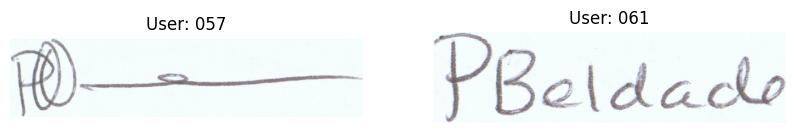

In [46]:
# Display one sample from first 2 users
plt.figure(figsize=(10,4))
for i, user in enumerate(users[:2]):
    user_folder = os.path.join(train_path, user)
    sample_image = os.path.join(user_folder, os.listdir(user_folder)[0])
    plt.subplot(1,2,i+1)
    plt.imshow(mpimg.imread(sample_image))
    plt.title(f"User: {user}")
    plt.axis('off')
plt.show()


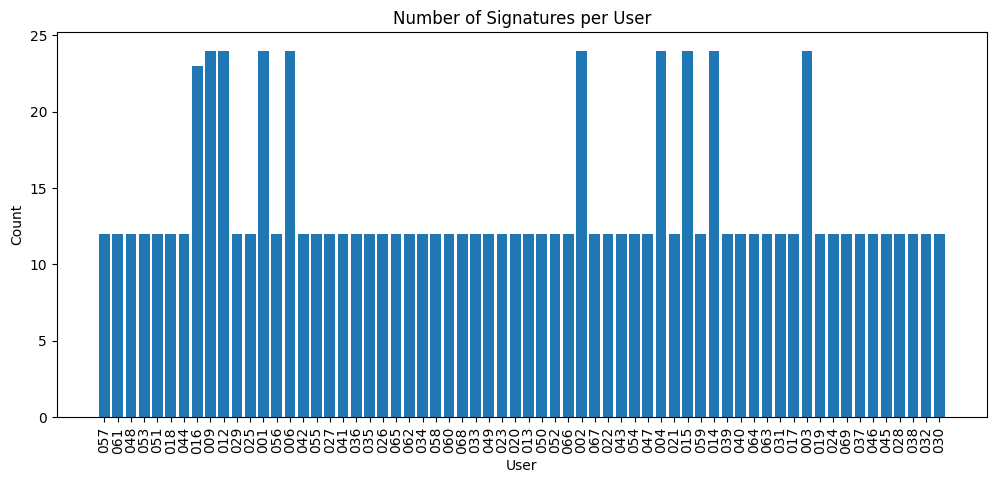

Total users: 64
Images per user (first 5): [('057', 12), ('061', 12), ('048', 12), ('053', 12), ('051', 12)]


In [47]:
# Count images per user
user_counts = {user: len(os.listdir(os.path.join(train_path, user))) for user in users}

plt.figure(figsize=(12,5))
plt.bar(user_counts.keys(), user_counts.values())
plt.xticks(rotation=90)
plt.title("Number of Signatures per User")
plt.xlabel("User")
plt.ylabel("Count")
plt.show()

print("Total users:", len(users))
print("Images per user (first 5):", list(user_counts.items())[:5])


#CNN

In [48]:
IMG_SIZE = (128, 128)

def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0
    img = np.expand_dims(img, axis=-1)
    return img


In [49]:
X = []
y = []

for user in users:
    user_folder = os.path.join(train_path, user)
    for img_file in os.listdir(user_folder):
        img_path = os.path.join(user_folder, img_file)
        X.append(preprocess_image(img_path))
        y.append(user)

X = np.array(X)
y = np.array(y)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

print("Data shape:", X.shape, y_categorical.shape)


Data shape: (887, 128, 128, 1) (887, 64)


In [50]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical
)
print("Train shape:", X_train.shape, "Validation shape:", X_val.shape)


Train shape: (709, 128, 128, 1) Validation shape: (178, 128, 128, 1)


In [51]:
def create_cnn(input_shape=(128,128,1), num_classes=len(users)):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

cnn_model = create_cnn()
cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,531,904 (24.92 MB)

 Trainable params: 6,531,904 (24.92 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
history = cnn_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val)
)


Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step - accuracy: 0.0255 - loss: 4.2245 - val_accuracy: 0.0281 - val_loss: 4.1540
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0308 - loss: 4.1543 - val_accuracy: 0.0281 - val_loss: 4.1370
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0256 - loss: 4.1178 - val_accuracy: 0.0787 - val_loss: 4.0242
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.1075 - loss: 3.8580 - val_accuracy: 0.3034 - val_loss: 2.8757
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2993 - loss: 2.8185 - val_accuracy: 0.5730 - val_loss: 1.7633
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4998 - loss: 1.9275 - val_accuracy: 0.7472 - val_loss: 1.1123
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6248 - loss: 1.4319 - val_accuracy: 0.8090 - val_loss: 0.7909
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7485 - loss: 0.9381 - val_accuracy: 0.8427 - 

In [53]:
y_pred = cnn_model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
print("Accuracy:", accuracy_score(y_true_classes, y_pred_classes))


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         5
           5       0.83      1.00      0.91         5
           6       0.62      1.00      0.77         5
           7       1.00      0.33      0.50         3
           8       1.00      1.00      1.00         5
           9       0.83      1.00      0.91         5
          10       0.71      1.00      0.83         5
          11       1.00      1.00      1.00         2
          12       0.75      1.00      0.86         3
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         2
          15       1.00      1.00      1.00         2
          16       

In [57]:
# --- Predictions on Validation Set ---
y_val_pred = cnn_model.predict(X_val)
y_val_classes = np.argmax(y_val_pred, axis=1)
y_true_val = np.argmax(y_val, axis=1)

print("=== CNN Validation Set Metrics ===")
print("Accuracy:", accuracy_score(y_true_val, y_val_classes))
print("Precision (macro):", precision_score(y_true_val, y_val_classes, average='macro'))
print("Recall (macro):", recall_score(y_true_val, y_val_classes, average='macro'))
print("F1 Score (macro):", f1_score(y_true_val, y_val_classes, average='macro'))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
=== CNN Validation Set Metrics ===
Accuracy: 0.9269662921348315
Precision (macro): 0.9532180059523809
Recall (macro): 0.9296875
F1 Score (macro): 0.9307557026307026


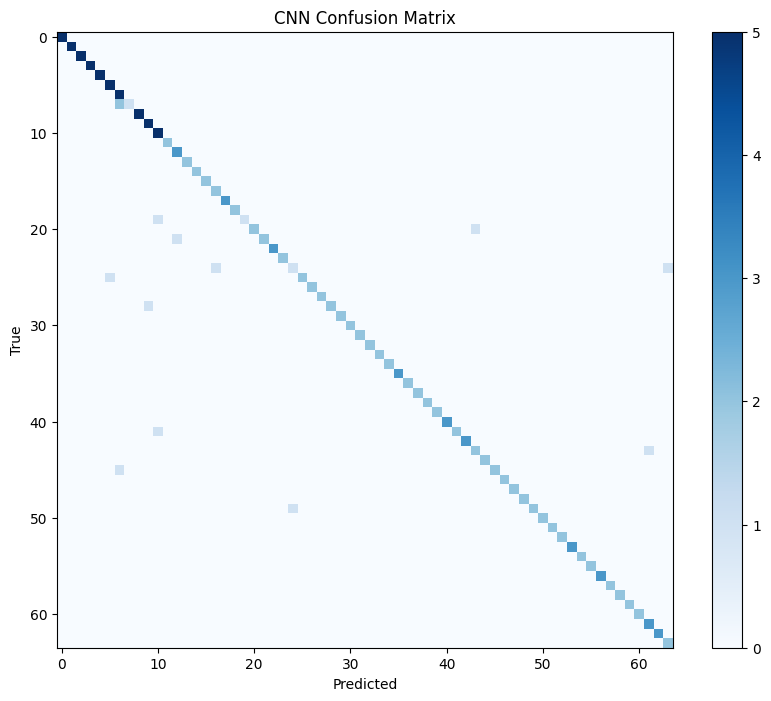

In [58]:
# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10,8))
plt.imshow(cm, cmap='Blues')
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


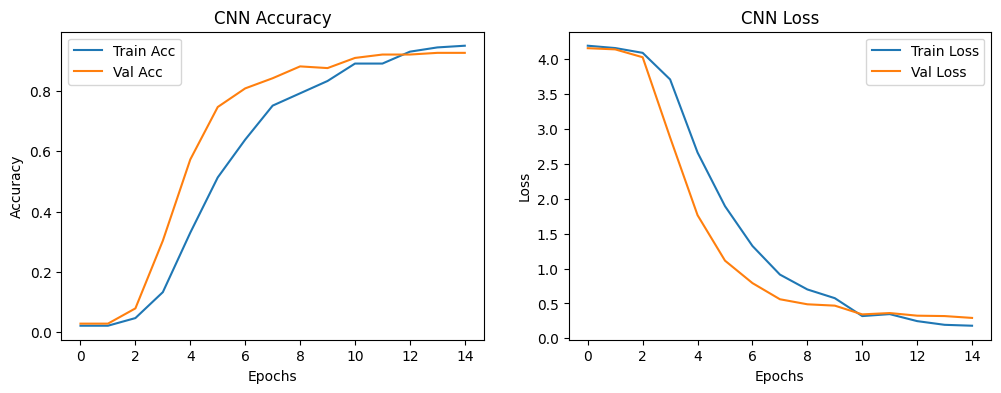

In [59]:
# Training curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

#HOG FEATURES

In [60]:
def extract_hog_features(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    fd, hog_img = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        visualize=True
    )
    return fd


# Prepare HOG dataset
X_hog = []
y_hog = []

for user in users:
    user_folder = os.path.join(train_path, user)
    for img_file in os.listdir(user_folder):
        X_hog.append(extract_hog_features(os.path.join(user_folder, img_file)))
        y_hog.append(user)

X_hog = np.array(X_hog)
y_hog_encoded = le.transform(y_hog)

# Split
X_train_hog, X_val_hog, y_train_hog, y_val_hog = train_test_split(
    X_hog, y_hog_encoded, test_size=0.2, random_state=42, stratify=y_hog_encoded
)

# Train SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_hog, y_train_hog)

# Evaluate
y_pred_hog = svm_model.predict(X_val_hog)
print("HOG + SVM Accuracy:", accuracy_score(y_val_hog, y_pred_hog))


HOG + SVM Accuracy: 0.9382022471910112


In [68]:
# ------------------------------
# 🔹 HOG + SVM Validation Metrics
# ------------------------------
y_val_pred_hog = svm_model.predict(X_val_hog)

print("=== HOG + SVM Validation Set Metrics ===")
print("Accuracy:", accuracy_score(y_val_hog, y_val_pred_hog))
print("Precision (macro):", precision_score(y_val_hog, y_val_pred_hog, average='macro'))
print("Recall (macro):", recall_score(y_val_hog, y_val_pred_hog, average='macro'))
print("F1 Score (macro):", f1_score(y_val_hog, y_val_pred_hog, average='macro'))


=== HOG + SVM Validation Set Metrics ===
Accuracy: 0.9382022471910112
Precision (macro): 0.953125
Recall (macro): 0.9270833333333334
F1 Score (macro): 0.9240868506493507


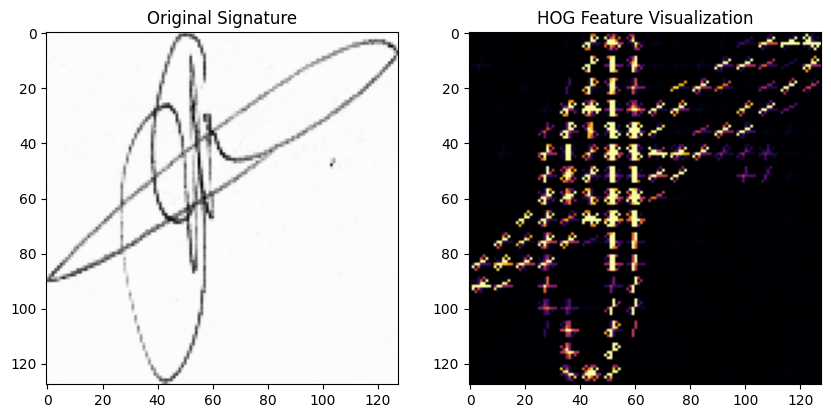

In [73]:
from skimage.feature import hog
from skimage import color, exposure

# Pick a random sample from your dataset
sample_user = random.choice(users)
sample_image = random.choice(os.listdir(os.path.join(train_path, sample_user)))
img_path = os.path.join(train_path, sample_user, sample_image)

# Read and compute HOG features
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, IMG_SIZE)
fd, hog_image = hog(img_resized, orientations=9, pixels_per_cell=(8,8),
                    cells_per_block=(2,2), visualize=True)

# Enhance visualization
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# Display
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_resized, cmap='gray')
plt.title("Original Signature")

plt.subplot(1,2,2)
plt.imshow(hog_image_rescaled, cmap='inferno')
plt.title("HOG Feature Visualization")
plt.show()


#SIFT FEATURES

In [65]:
# SIFT features require fixed length vectors; we'll pad/truncate to 128*50 features
def extract_sift_features(img_path, max_features=50):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    sift = cv2.SIFT_create()
    kp, des = sift.detectAndCompute(img, None)

    # If no descriptors found, use zeros
    if des is None:
        des = np.zeros((max_features, 128))

    # Pad or truncate to fixed number of features
    if des.shape[0] > max_features:
        des = des[:max_features, :]
    elif des.shape[0] < max_features:
        pad = np.zeros((max_features - des.shape[0], 128))
        des = np.vstack([des, pad])

    return des.flatten()  # Flatten to 1D array

# Prepare SIFT dataset
X_sift = []
y_sift = []

for user in users:
    user_folder = os.path.join(train_path, user)
    for img_file in os.listdir(user_folder):
        X_sift.append(extract_sift_features(os.path.join(user_folder, img_file)))
        y_sift.append(user)

X_sift = np.array(X_sift)
y_sift_encoded = le.transform(y_sift)

# Split
X_train_sift, X_val_sift, y_train_sift, y_val_sift = train_test_split(
    X_sift, y_sift_encoded, test_size=0.2, random_state=42, stratify=y_sift_encoded
)

# Train SVM
svm_sift = SVC(kernel='linear')
svm_sift.fit(X_train_sift, y_train_sift)

# Evaluate
y_pred_sift = svm_sift.predict(X_val_sift)
print("SIFT + SVM Accuracy:", accuracy_score(y_val_sift, y_pred_sift))


SIFT + SVM Accuracy: 0.33707865168539325


In [69]:
# ------------------------------
# 🔹 SIFT + SVM Validation Metrics
# ------------------------------
y_val_pred_sift = svm_sift.predict(X_val_sift)

print("\n=== SIFT + SVM Validation Set Metrics ===")
print("Accuracy:", accuracy_score(y_val_sift, y_val_pred_sift))
print("Precision (macro):", precision_score(y_val_sift, y_val_pred_sift, average='macro'))
print("Recall (macro):", recall_score(y_val_sift, y_val_pred_sift, average='macro'))
print("F1 Score (macro):", f1_score(y_val_sift, y_val_pred_sift, average='macro'))


=== SIFT + SVM Validation Set Metrics ===
Accuracy: 0.33707865168539325
Precision (macro): 0.2901223776223776
Recall (macro): 0.2973958333333333
F1 Score (macro): 0.27254268658220865


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/tmp/ipython-input-1486711184.py:33: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


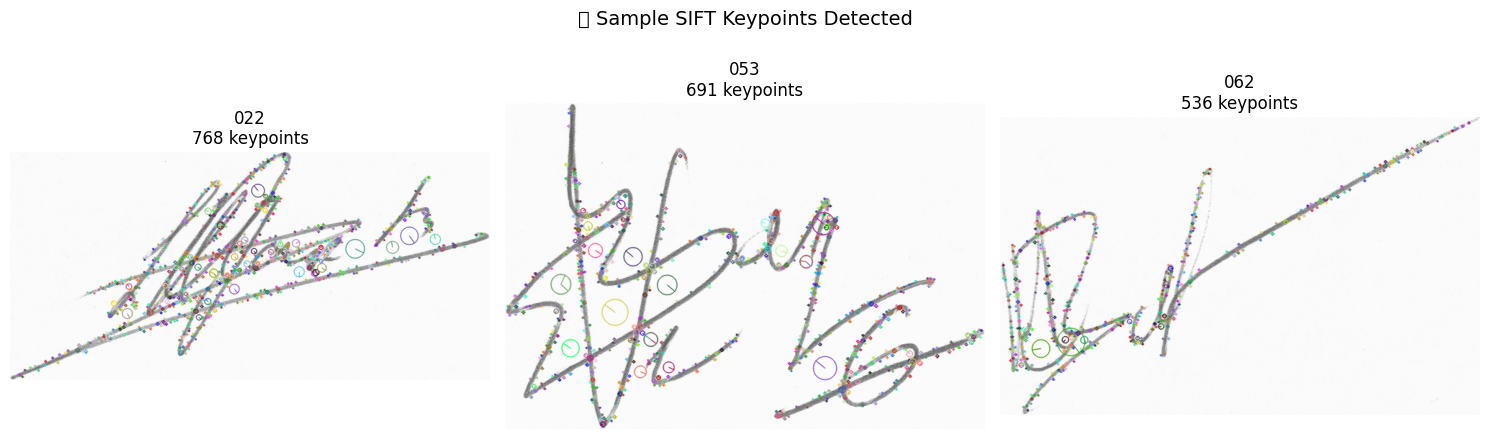

In [76]:
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ------------------------------
# 1️⃣ Visualize SIFT keypoints on sample images (fixed version)
# ------------------------------
plt.figure(figsize=(15,5))

for i in range(3):
    user = random.choice(users)
    user_folder = os.path.join(train_path, user)
    img_file = random.choice(os.listdir(user_folder))
    img_path = os.path.join(user_folder, img_file)

    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️ Skipping unreadable image: {img_path}")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    kp, des = sift.detectAndCompute(gray, None)
    img_kp = cv2.drawKeypoints(gray, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    plt.subplot(1, 3, i+1)
    plt.imshow(img_kp, cmap='gray')
    plt.title(f"{user}\n{len(kp)} keypoints")
    plt.axis('off')

plt.suptitle("🔹 Sample SIFT Keypoints Detected", fontsize=14)
plt.tight_layout()
plt.show()



/tmp/ipython-input-507239430.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette='viridis')


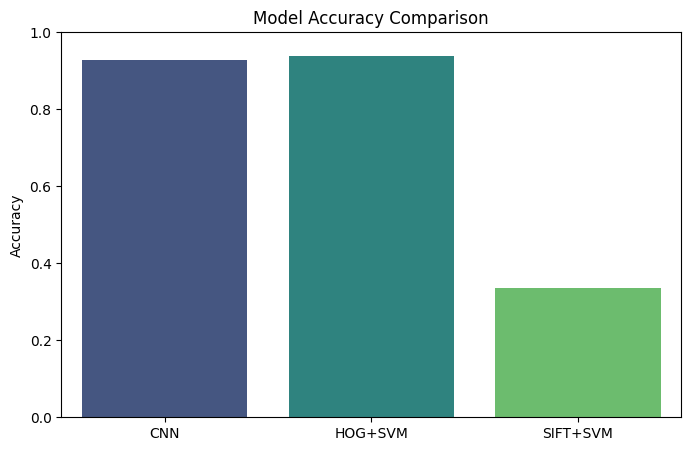

In [70]:
import seaborn as sns

# Accuracy comparison
cnn_acc = accuracy_score(y_true_classes, y_pred_classes)
hog_acc = accuracy_score(y_val_hog, y_pred_hog)
sift_acc = accuracy_score(y_val_sift, y_pred_sift)

model_names = ['CNN', 'HOG+SVM', 'SIFT+SVM']
accuracies = [cnn_acc, hog_acc, sift_acc]

plt.figure(figsize=(8,5))
sns.barplot(x=model_names, y=accuracies, palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


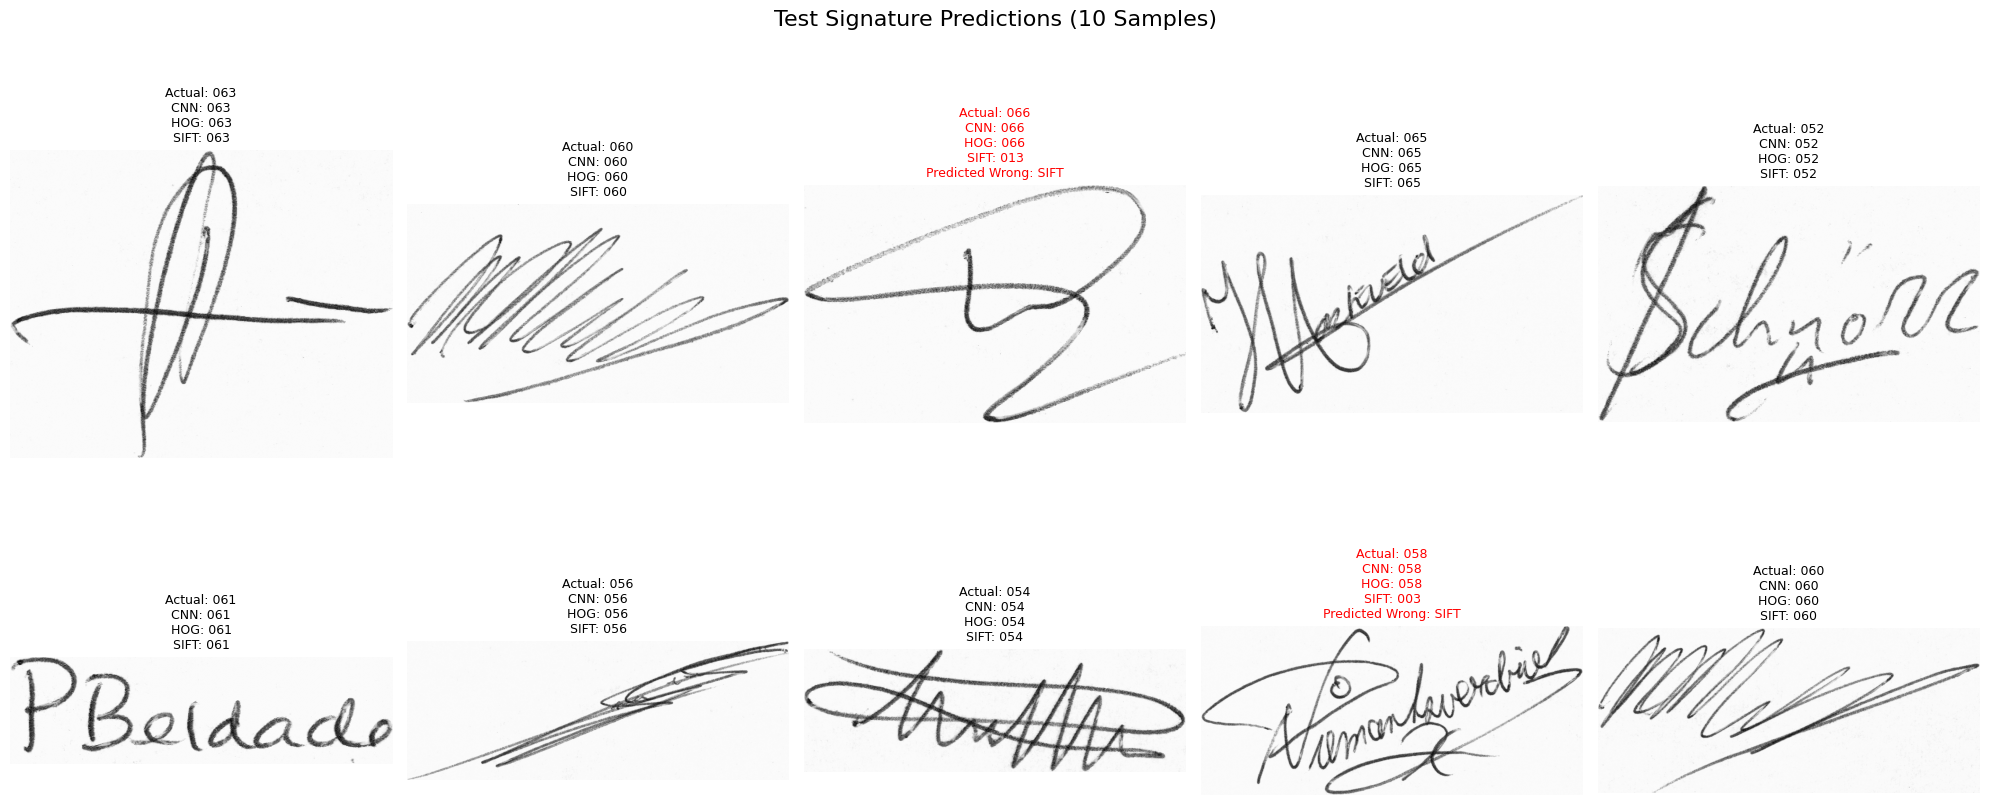

In [71]:
# --- Display 10 random test images with wrong predictions highlighted in title ---
plt.figure(figsize=(20,10))

for i, (img_path, actual_user) in enumerate(sample_images):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Preprocess for CNN
    img_cnn = cv2.resize(img, IMG_SIZE) / 255.0
    img_cnn = np.expand_dims(img_cnn, axis=(0,-1))

    # Preprocess for HOG
    img_hog = extract_hog_features(img_path).reshape(1,-1)

    # Preprocess for SIFT
    img_sift = extract_sift_features(img_path).reshape(1,-1)

    # Predictions
    pred_cnn = le.inverse_transform([np.argmax(cnn_model.predict(img_cnn))])[0]
    pred_hog = le.inverse_transform([svm_model.predict(img_hog)[0]])[0]
    pred_sift = le.inverse_transform([svm_sift.predict(img_sift)[0]])[0]

    # Identify wrong predictions
    wrong_models = []
    if pred_cnn != actual_user:
        wrong_models.append("CNN")
    if pred_hog != actual_user:
        wrong_models.append("HOG")
    if pred_sift != actual_user:
        wrong_models.append("SIFT")

    # Build title string
    title_str = f"Actual: {actual_user}\nCNN: {pred_cnn}\nHOG: {pred_hog}\nSIFT: {pred_sift}"
    if wrong_models:
        title_str += "\n" + "Predicted Wrong: " + ", ".join(wrong_models)

    # Plot image
    plt.subplot(2,5,i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')

    # Display title
    plt.title(title_str, fontsize=9, color='red' if wrong_models else 'black')

plt.suptitle("Test Signature Predictions (10 Samples)", fontsize=16)
plt.tight_layout()
plt.show()
